<a href="https://colab.research.google.com/github/Madelavishnu/Pytorch/blob/main/Moon_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from sklearn.datasets import make_moons

x_moons, y_moons = make_moons(
    n_samples=1000,
    noise=0.15,
    random_state=42
)


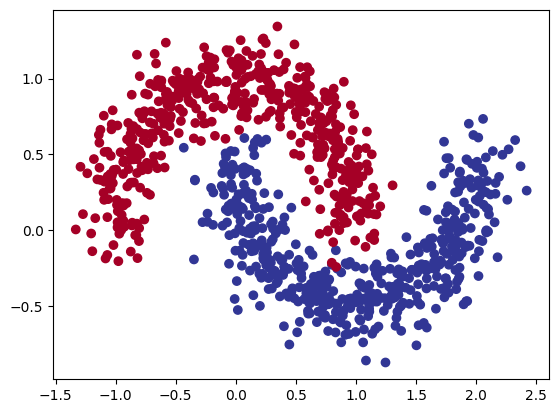

In [15]:
import matplotlib.pyplot as plt
plt.scatter(x = x_moons[:,0],y = x_moons[:,1], c = y_moons,cmap = plt.cm.RdYlBu);

In [16]:
x_moons[:10],y_moons[:10]

(array([[-0.08156811,  0.48221119],
        [ 1.08733336, -0.38115925],
        [ 0.83172491, -0.13313471],
        [ 0.20033884, -0.50030007],
        [-0.82495264,  0.53952635],
        [ 0.63810778, -0.16336258],
        [ 0.28050215, -0.19559014],
        [-0.08582997,  0.50649552],
        [ 1.58829295, -0.31949426],
        [ 0.73681565,  0.91061278]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [17]:
import torch
x = torch.from_numpy(x_moons).type(torch.float)
y = torch.from_numpy(y_moons).type(torch.long)

In [18]:
x[:10], y[:10]

(tensor([[-0.0816,  0.4822],
         [ 1.0873, -0.3812],
         [ 0.8317, -0.1331],
         [ 0.2003, -0.5003],
         [-0.8250,  0.5395],
         [ 0.6381, -0.1634],
         [ 0.2805, -0.1956],
         [-0.0858,  0.5065],
         [ 1.5883, -0.3195],
         [ 0.7368,  0.9106]]),
 tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [21]:
from sklearn.model_selection import train_test_split

x_moon_train,x_moon_test,y_moon_train, y_moon_test = train_test_split(x,y ,test_size = 0.2, random_state = 42)

In [26]:
x_moon_train.shape, y_moon_train.unique()   # in features = 2, out features = 1

(torch.Size([800, 2]), tensor([0, 1]))

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [29]:
import torch.nn as nn

class MoonModelV0(nn.Module):
  def __init__(self,input_features,output_features,hidden_units):
    super().__init__()
    self.linear_layer = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = output_features)
    )

  def forward(self,x):
    return self.linear_layer(x)

model_0 = MoonModelV0(input_features=2,output_features=1,hidden_units=10).to(device)
model_0

MoonModelV0(
  (linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [30]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [31]:
from sklearn.metrics import accuracy_score

In [34]:
x_moon_train.shape, y_moon_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [43]:
x_moon = torch.unsqueeze(y_moon_train,dim = 1)
x_moon.shape

torch.Size([800, 1])

In [47]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

x_moon_train, y_moon_train = x_moon_train.to(device), y_moon_train.to(device)
x_moon_test, y_moon_test = x_moon_test.to(device), y_moon_test.to(device)

for epoch in range(epochs):

    # -------- TRAIN --------
    model_0.train()

    y_logits = model_0(x_moon_train)                    # (N,1)
    loss = loss_fn(y_logits, y_moon_train.unsqueeze(1).float())

    y_pred = torch.round(torch.sigmoid(y_logits))
    acc = accuracy_score(
    y_moon_train.detach().cpu(),
    y_pred.detach().squeeze().cpu()
)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # -------- TEST --------
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(x_moon_test)
        test_loss = loss_fn(
            test_logits,
            y_moon_test.unsqueeze(1).float()
        )

        test_pred = torch.round(torch.sigmoid(test_logits))
        test_acc = accuracy_score(

             y_moon_test.detach().cpu(),
             test_pred.detach().squeeze().cpu()
             )


    if epoch % 10 == 0:
        print(
            f"epoch: {epoch} | "
            f"loss: {loss:.4f}, acc: {acc*100:.2f}% | "
            f"test_loss: {test_loss:.4f}, test_acc: {test_acc*100:.2f}%"
        )


epoch: 0 | loss: 0.3775, acc: 83.62% | test_loss: 0.3961, test_acc: 81.50%
epoch: 10 | loss: 0.3749, acc: 83.88% | test_loss: 0.3933, test_acc: 81.50%
epoch: 20 | loss: 0.3724, acc: 83.88% | test_loss: 0.3905, test_acc: 81.50%
epoch: 30 | loss: 0.3699, acc: 83.88% | test_loss: 0.3878, test_acc: 81.50%
epoch: 40 | loss: 0.3675, acc: 83.88% | test_loss: 0.3851, test_acc: 82.00%
epoch: 50 | loss: 0.3651, acc: 84.00% | test_loss: 0.3825, test_acc: 83.00%
epoch: 60 | loss: 0.3628, acc: 84.12% | test_loss: 0.3799, test_acc: 83.00%
epoch: 70 | loss: 0.3605, acc: 84.12% | test_loss: 0.3774, test_acc: 83.00%
epoch: 80 | loss: 0.3583, acc: 84.25% | test_loss: 0.3749, test_acc: 83.00%
epoch: 90 | loss: 0.3561, acc: 84.25% | test_loss: 0.3724, test_acc: 83.00%


In [54]:
model_0 = model_0.to(device)


In [55]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_moon_test)          # (N,1)
    y_probs = torch.sigmoid(y_logits)        # probabilities
    y_pred = torch.round(y_probs)            # 0 or 1


In [56]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


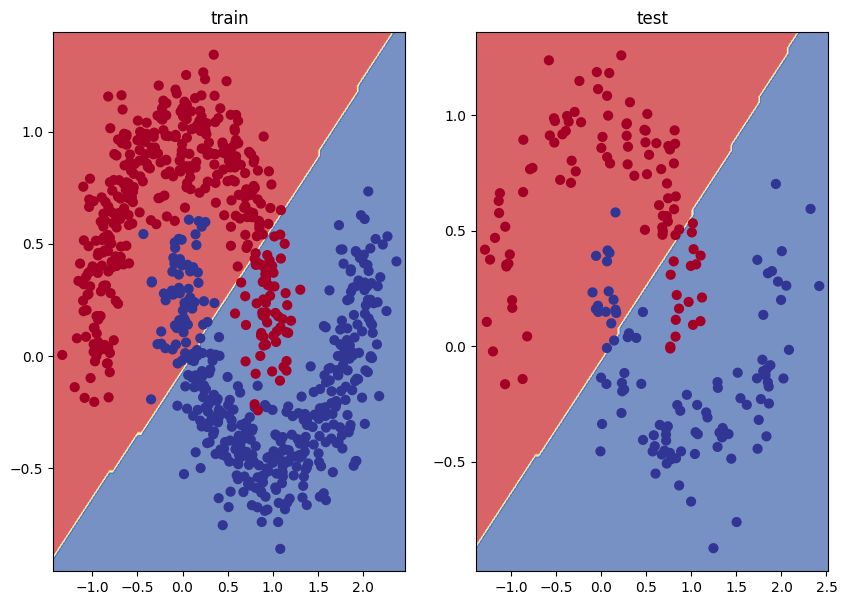

In [57]:
plt.figure(figsize = (10,7))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_0,x_moon_train,y_moon_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_0,x_moon_test,y_moon_test)